In [1]:
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
import seaborn as sns
import numpy as np
import Funciones_ML as ML #Funciones generales
from scipy import stats

In [3]:
# url = "https://raw.githubusercontent.com/dragonnomada/ml-cic-febrero-2026/refs/heads/main/titanic.csv"

# titanic = pandas.read_csv(url)

data = pd.read_csv("titanic.csv")
data_copy = data
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Descripción de Columnas**

| Columna      | Tipo de Dato | Descripción |
|--------------|-------------|-------------|
| PassengerId  | Entero      | Identificador único de cada pasajero. |
| Survived     | Entero (0/1)| Indica si el pasajero sobrevivió. 0 = No, 1 = Sí. |
| Pclass       | Entero      | Clase del boleto: 1 = Primera, 2 = Segunda, 3 = Tercera. |
| Name         | Texto       | Nombre completo del pasajero. |
| Sex          | Texto       | Sexo del pasajero (male / female). |
| Age          | Decimal     | Edad en años. Puede contener valores nulos. |
| SibSp        | Entero      | Número de hermanos/esposo(a) a bordo. |
| Parch        | Entero      | Número de padres/hijos a bordo. |
| Ticket       | Texto       | Número de boleto. |
| Fare         | Decimal     | Precio pagado por el boleto. |
| Cabin        | Texto       | Número de cabina. Puede contener valores nulos. |
| Embarked     | Texto       | Puerto de embarque: C = Cherbourg, Q = Queenstown, S = Southampton. |

# Funciones

In [5]:
def grupoEdad(age):
    if age == np.nan:
        return np.nan
    if age <= 8:
        return "Child"
    elif age < 65:
        return "Adult"
    else:
        return "Old"

# Preparación de datos

In [7]:
# Number of rows
print(f"No_filas:\n {data.shape[0]} \n")

# Column names
print(f"Lista de columnas: \n {data.columns.tolist()} \n")

# Data types
print(f"Tipo de datos:\n{data.dtypes}")

No_filas:
 891 

Lista de columnas: 
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'] 

Tipo de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Valores faltantes

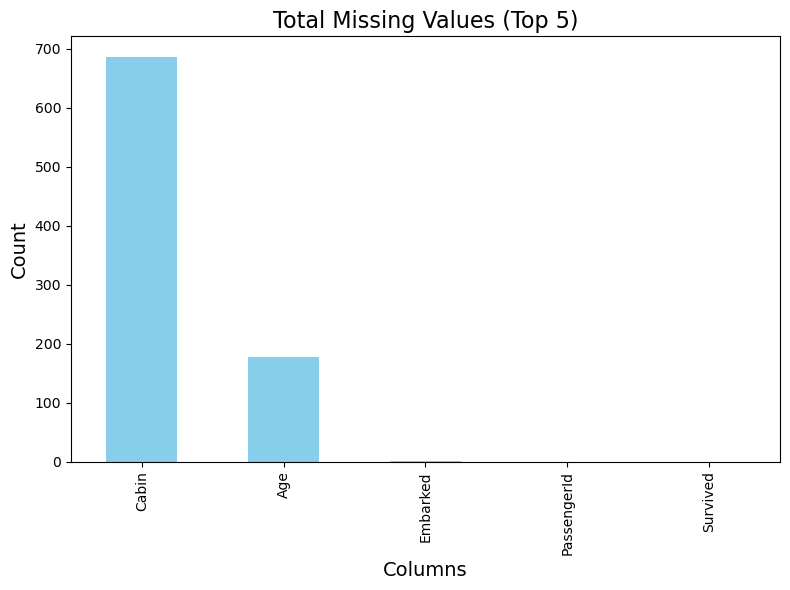

In [11]:
ML.plot_missing_values(data, top_n=5)  # Para mostrar las 5 columnas con más valores faltantes

A partir de lo anterior, podemos observar que la columna  <code> Cabin </code>, <code>Age</code> y <code>  Embarked </code> presenta valores faltantes. En consecuencia, procederemos a investigar el **porcentaje de valores nulos** que contiene esta columna en el conjunto de datos.

In [13]:
ML.resumen_faltantes(data)


Resumen de faltantes por columna:



,faltantes,porcentaje_%
Cabin,687,77.104
Age,177,19.865
Embarked,2,0.224
PassengerId,0,0.000
Survived,0,0.000
Pclass,0,0.000
Name,0,0.000
Sex,0,0.000
SibSp,0,0.000
Parch,0,0.000


Con un alto porcentaje de nulos, cualquier imputación (relleno de valores nulos) podría introducir un sesgo en el análisis o modelo. 
La columna <code> Cabin </code> tiene un $77.1$% de valores nulos, lo cual es un porcentaje extremadamente alto, por lo cual es más eficiente eliminarla del análisis y evitar complicaciones innecesarias

In [15]:
null_rows_idx = data.isnull().any(axis=1) #Nos quedamos con el índice en donde tenemos los valores nulos
data.loc[null_rows_idx].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [17]:
# Eliminar la columna 'Cabin'
data = data.drop('Cabin', axis=1)

Imprimimos las primeros $5$ filas donde hay valores nulos y observamos que ya no aparece la columna <code> Cabin </code>

In [19]:
data.loc[null_rows_idx].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S


In [21]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [23]:
# Eliminar filas donde las columnas 'Age' o 'Embarked' tienen valores NaN
data = data.dropna(subset=['Age', 'Embarked'])

Eliminamos las filas en donde las columnas <code> Age </code> y <code> Embarked </code> tienen valores nulos.

In [25]:
ML.resumen_faltantes(data)


Resumen de faltantes por columna:



,faltantes,porcentaje_%
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


Observamos que el dataframe ya no tiene valores nulos.

In [27]:
# Filtrar filas con valores nulos en alguna columna
filas_nulas = data[data.isnull().any(axis=1)]
filas_nulas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


Tener valores duplicados puede afectar nuestro análisis, por lo que conviene comprobar si hay duplicados en nuestros datos. Usaremos la función <code> duplicated() </code> de Pandas y buscaremos por la columna 'PassengerId', que contiene un número de índice único para cada entrada.

In [29]:
duplicate = data[data.duplicated([ 'PassengerId'])]
duplicate

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


Observamos que no tiene duplicados

**Variables que no aportan valor predictivo directo**

Las siguientes variables no aportan valor predictivo directo o funcionan únicamente como identificadores, por lo que comúnmente se eliminan en un modelo base de Machine Learning:

| Columna       | ¿Por qué no se usa? |
|---------------|----------------------|
| **PassengerId** | Es solo un identificador único. No tiene significado estadístico ni relación con la variable objetivo. |
| **Name**        | Es texto libre. No aporta directamente información cuantificable, salvo que se realice ingeniería de características (por ejemplo, extraer títulos como *Mr*, *Mrs*, etc.). |
| **Ticket**      | Funciona prácticamente como un identificador. Presenta alta cardinalidad y poco significado predictivo directo. |
| **Cabin**       | Contiene una gran cantidad de valores nulos y alta variabilidad. Solo podría aprovecharse extrayendo información como la letra del deck. |

In [31]:
data = data.drop( ["PassengerId", "Name", "Ticket"], axis=1)
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

Realizamos un gráfico de pastel, para revisar el balanceo de clase.

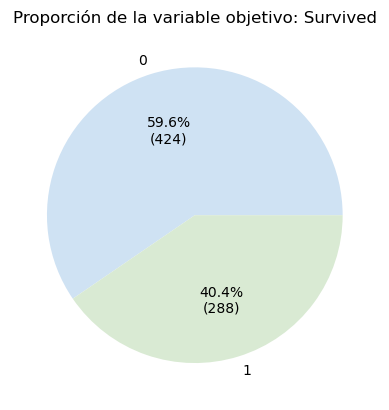

In [33]:
ML.Grafico_pastel_objetivo(data, 'Survived', colors=None)

In [35]:
ML.diagnostico_balance_clases_binaria(data, target='Survived')


[Diagnóstico de balance] Variable objetivo: 'Survived'
Total muestras: 712

Clase 0: 424 (59.6%)
Clase 1: 288 (40.4%)

IR (Imbalance Ratio) = 1.472 → Balance razonable (IR < 1.5)


Con el gráfico de pastel y calculando el **Imbalance Ratio** observamos que la clase mayoritaria es solo $1.47$ veces más grande que la minoritaria.
Eso es una diferencia pequeña en términos prácticos, ni tenemos problemas de desbalanceo.

In [37]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [39]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.356462,-0.082446,-0.015523,0.095265,0.266100
Pclass,-0.356462,1.000000,-0.365902,0.065187,0.023666,-0.552893
Age,-0.082446,-0.365902,1.000000,-0.307351,-0.187896,0.093143
SibSp,-0.015523,0.065187,-0.307351,1.000000,0.383338,0.139860
Parch,0.095265,0.023666,-0.187896,0.383338,1.000000,0.206624
Fare,0.266100,-0.552893,0.093143,0.139860,0.206624,1.000000


In [41]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

| Columna      | Tipo Variable| Descripción |
|--------------|-------------|-------------|
| Survived     | Categórica binaria (Variable objetivo) | Indica si el pasajero sobrevivió. 0 = No, 1 = Sí. |
| Pclass       | Categorica ordinal      | Clase del boleto: 1 = Primera, 2 = Segunda, 3 = Tercera. |
| Sex          | Categorica nominal     | Sexo del pasajero (male / female). |
| Age          | Númerica    | Edad en años. Puede contener valores nulos. |
| SibSp        | Númerica discreta   | Número de hermanos/esposo(a) a bordo. |
| Parch        | Númerica discreta      | Número de padres/hijos a bordo. |
| Fare         | Númerica continua    | Precio pagado por el boleto. |
| Embarked     | Categorica nominal      | Puerto de embarque: C = Cherbourg, Q = Queenstown, S = Southampton. |

Una forma alternativa de comprobar si hay índices duplicados en nuestro conjunto de datos es mediante la función  `index.is_unique`

In [43]:
data.index.is_unique

True

## Manejo de valores atípicos

En estadística, un **valor atípico** es un punto de observación distante de otras observaciones. Un valor atípico puede deberse a errores en la recopilación o registro de datos, o a la alta variabilidad natural de los puntos de datos. El tratamiento de un valor atípico depende en gran medida de los datos o del tipo de análisis que se realice. Los valores atípicos pueden afectar significativamente a nuestros modelos y ser una valiosa fuente de información, brindándonos información sobre comportamientos específicos.

Existen muchas maneras de descubrir valores atípicos en nuestros datos. Podemos realizar análisis univariados (utilizando un análisis de una variable) o análisis multivariados (utilizando dos o más variables). Una de las maneras más sencillas de detectar un valor atípico es inspeccionar los datos visualmente, mediante diagramas de caja o de dispersión.

1. **Análisis univariado:**
Un diagrama de caja es un método para representar gráficamente grupos de datos numéricos a través de sus cuartiles. Los diagramas de caja también pueden tener líneas que se extienden verticalmente desde las cajas (líneas de puntos) que indican variabilidad fuera de los cuartiles superior e inferior. Los valores atípicos pueden representarse como puntos individuales. 

2. **Análisis Z-Score:**
El Z-score es una herramienta matemática utilizada para identificar valores atípicos. Representa el número de desviaciones estándar que separan un valor observado o dato de la media de los datos. En otras palabras, el Z-score cuantifica la relación entre un punto de datos y la media y desviación estándar de un conjunto de puntos. Los valores que se alejan considerablemente de la media (ya sea hacia valores muy altos o muy bajos) se consideran atípicos. Generalmente, se utiliza un umbral de ±$3$ para identificar los valores atípicos. Por ejemplo, si el Z-score de un dato es mayor a $3$ o menor a -$3$, se considerará un valor atípico.
$$ Z = \frac{X - \mu}{\sigma} $$


### Análisis univariado

#### Age

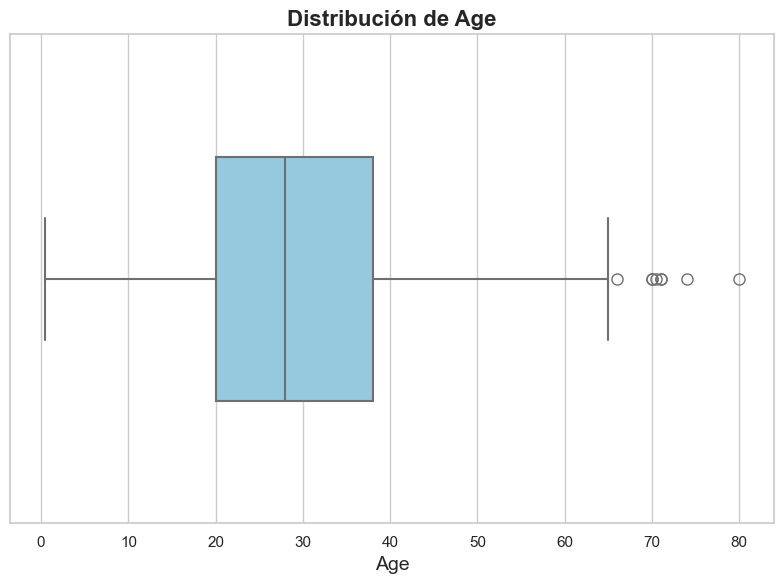

In [45]:
ML.crear_boxplot(data, 'Age')

In [61]:
# Detectar outliers en la columna 'Age'
Outliers_Age = ML.detect_outliers_iqr_indices(data, 'Age')
Outliers_Age

{'outlier_indices': [33, 96, 116, 493, 630, 672, 745, 851],
 'n_outliers': 8,
 'prop_outliers': 0.011,
 'q1': 20.0,
 'q3': 38.0,
 'iqr': 18.0,
 'lim_inf': -7.0,
 'lim_sup': 65.0}

In [63]:
# Ver datos en el DataFrame original
data.loc[Outliers_Age['outlier_indices']]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
33,0,2,male,66.0,0,0,10.5000,S
96,0,1,male,71.0,0,0,34.6542,C
116,0,3,male,70.5,0,0,7.7500,Q
493,0,1,male,71.0,0,0,49.5042,C
630,1,1,male,80.0,0,0,30.0000,S
672,0,2,male,70.0,0,0,10.5000,S
745,0,1,male,70.0,1,1,71.0000,S
851,0,3,male,74.0,0,0,7.7750,S


Se identificaron 8 valores atípicos en la columna <code>Age</code>, sin embargo, no se realizarán ajustes, ya que edades como 80 años son completamente plausibles en el conjunto de datos.

#### Fare

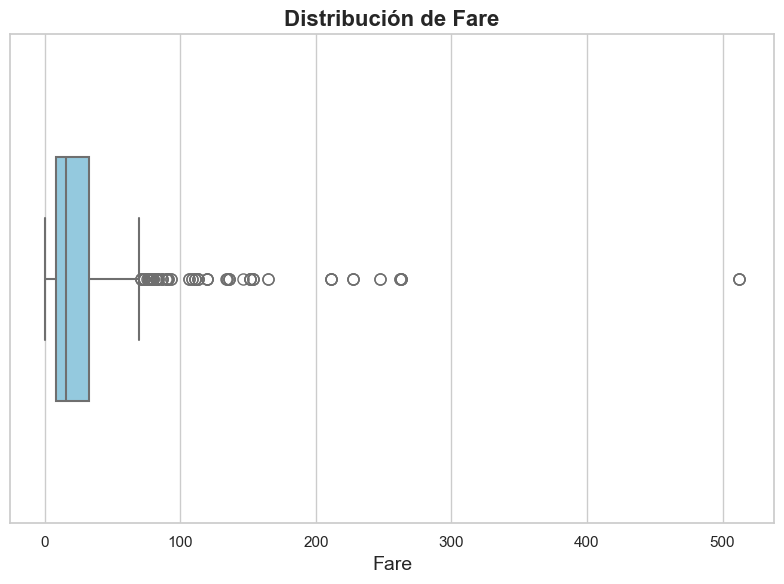

In [75]:
ML.crear_boxplot(data, 'Fare')

In [73]:
# Detectar outliers en la columna 'Age'
Outliers_Fare = ML.detect_outliers_iqr_indices(data, 'Fare') 

In [83]:
Outliers_Fare[ 'n_outliers']

95

In [88]:
Outliers_Fare['prop_outliers']

0.133

En este caso, se tienen $95$ valores atípicos para la columna <code> Fare </code>, que es aproximadamente el $13$\% .

In [79]:
data['Fare'].describe()

count    712.000000
mean      34.567251
std       52.938648
min        0.000000
25%        8.050000
50%       15.645850
75%       33.000000
max      512.329200
Name: Fare, dtype: float64

In [77]:
# Ver datos en el DataFrame original
data.loc[Outliers_Fare['outlier_indices']]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
1,1,1,female,38.0,1,0,71.2833,C
27,0,1,male,19.0,3,2,263.0000,S
34,0,1,male,28.0,1,0,82.1708,C
52,1,1,female,49.0,1,0,76.7292,C
62,0,1,male,45.0,1,0,83.4750,S
...,...,...,...,...,...,...,...,...
802,1,1,male,11.0,1,2,120.0000,S
820,1,1,female,52.0,1,1,93.5000,S
835,1,1,female,39.0,1,1,83.1583,C
856,1,1,female,45.0,1,1,164.8667,S


### Análisis Z-Score:

In [ ]:
data['Age_Stats'] = stats.zscore(data['Age'])
data[['Age_Stats', 'Age']].describe().round(3)

Los resultados escalados muestran una media de $0.0$ y una desviación estándar de $1.0$, lo que indica que los valores transformados se ajustan al modelo de escala z. El valor máximo de $3.47$ es una prueba más de la presencia de valores atípicos, ya que se sitúa muy por encima del límite de la puntuación $z$ de +$3$.

In [ ]:
data['Fare_Stats'] = stats.zscore(data['Fare'])
data[['Fare_Stats', 'Fare']].describe().round(3)

Los resultados escalados muestran una media de $0.0$ y una desviación estándar de $1.0$, lo que indica que los valores transformados se ajustan al modelo de escala z. El valor máximo de $9.031$ es una prueba más de la presencia de valores atípicos, ya que se sitúa muy por encima del límite de la puntuación $z$ de +$3$.

In [ ]:
num_cols = data.select_dtypes(include=[np.number]).columns
num_cols

In [ ]:
ML.crear_boxplot(data, 'Age')

In [ ]:
data['Age'].describe()

In [ ]:
outliers_info = detect_outliers_iqr_indices(data, 'Age')
print(outliers_info)

In [ ]:
# Ver directamente los datos en el DataFrame original
data.loc[outliers_info['outlier_indices']]

In [ ]:
def iqr_outlier_stats(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return 0, 0.0, np.nan, np.nan, np.nan, np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
    prop_out = n_out / len(s)
    return n_out, prop_out, q1, q3, lim_inf, lim_sup

In [ ]:
data.columns

In [ ]:
data['Age_Stats'] = stats.zscore(data['Age'])
data[['Age','Age_Stats']].describe().round(3)

In [ ]:
data.sort_values(by = 'Age', ascending = False)[:10]

In [ ]:
crear_boxplot(data, 'Fare')

In [ ]:
data.sort_values(by = 'Fare', ascending = False)[:10]

Como podemos ver en estos dos gráficos, tenemos algunos puntos fuera del área del diagrama de caja y que se desvían considerablemente del resto de la población. Su eliminación o conservación dependerá en gran medida de la comprensión de nuestros datos y del tipo de análisis que se realice.

In [ ]:
y = titanic["Survived"] # Respuesta categórica (2 clases / binaria)

In [ ]:
x1 = data["Age"] # Informativa numérica (positiva)


def grupoEdad(age):
    if age == np.nan:
        return np.nan
    if age <= 8:
        return "Child"
    elif age < 65:
        return "Adult"
    else:
        return "Old"

x2 = x1.map(grupoEdad)

seaborn.kdeplot(x=x1, hue=x2)

In [ ]:
# y vs x1
# categórico vs numérico (cat-num)

seaborn.kdeplot(x=x1, hue=y)

In [ ]:
seaborn.jointplot(x=x1, y=y, hue=y)

In [ ]:
# y vs x2
# categórica vs categórica (cat-cat)

r1 = pandas.DataFrame([x2, y]).T.value_counts().unstack()
r1

In [ ]:
r1.div(r1.sum(axis=1), axis=0)

In [ ]:
seaborn.heatmap(r1.div(r1.sum(axis=1), axis=0), cmap="coolwarm")

In [ ]:
seaborn.heatmap(r1.div(r1.sum(axis=1), axis=0), cmap="BuPu")

In [ ]:
x2.value_counts()

In [ ]:
X = pandas.DataFrame([x1, x2 == "Child", x2 == "Old"], index=["age", "child", "old"]).T.dropna()

X.sample(10)

In [ ]:
X.shape

In [ ]:
y1 = y[X.index]

y1.shape

##  Árboles de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(
    max_depth=4
)

model.fit(X, y1)

In [ ]:
from matplotlib import pyplot

figure, axes = pyplot.subplots(figsize=(30, 20))

plot_tree(model, ax=axes)

pyplot.show()

In [ ]:
y1p = model.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [ ]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

## Curva logística

In [ ]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()

model2.fit(X, y1)

In [ ]:
y1p = model2.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

In [ ]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [ ]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

In [ ]:
seaborn.regplot(x=X["age"], y=y1, logistic=True)

## Más características

In [ ]:
titanic["Pclass"].value_counts()

In [ ]:
x3 = titanic["Sex"] == "female"
x4 = titanic["Pclass"] == 1
x5 = titanic["Pclass"] == 2
x6 = ~titanic["Cabin"].isna()

In [ ]:
X = pandas.DataFrame([x1, x2 == "Child", x2 == "Old", x3, x4, x5, x6], index=["age", "child", "old", "female", "1-class", "2-class", "cabin"]).T.dropna()

X

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(
    max_depth=4
)

model.fit(X, y1)

In [ ]:
from matplotlib import pyplot

figure, axes = pyplot.subplots(figsize=(30, 20))

plot_tree(model, ax=axes)

pyplot.show()

In [ ]:
y1p = model.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

In [ ]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [ ]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

In [ ]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()

model2.fit(X, y1)

In [ ]:
y1p = model2.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

In [ ]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [ ]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T